## **Duffing oscillator (SINDy)**


## **I. Setup and Preprocessing**


In [5]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
sys.path.append('../utilities')

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import DataGenerator as DG


### **1.2 Training Data**


#### Create dataset


[3.48357077 0.30867849]
Guess highest order polynomial: 3


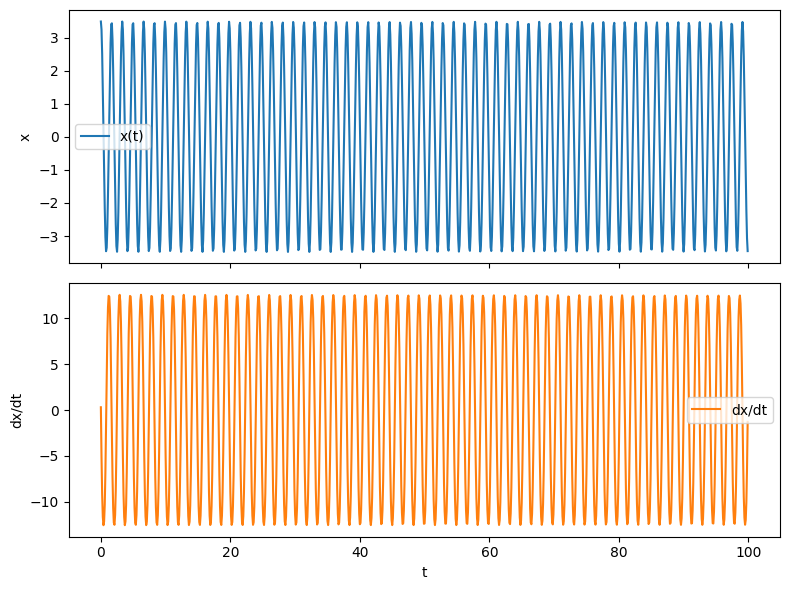

Training input shape: (1000, 2)
Training output shape: (1000, 2)


In [6]:
# Specify the model type
MY_MODEL = 'duffing'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

# Generate data based on the specified model type
num_traj = 1
data_initial_conditions = []
for i in range(num_traj):
    x0 = np.random.normal(1, 5.0, size=2)  # [x, dx/dt]
    data_initial_conditions.append(x0)

print(data_initial_conditions[0])

data_T = 100.0       # Length of the data (T)
data_dt = 0.1   # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, random_state=SEED)

duffing_p = [0.0001, 10, 0.5]  # [damping, linear, cubic]
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(
    MY_MODEL, duffing_p, method='DOP853'
)

print('Guess highest order polynomial:', guess_highest_order_polynomial)

# Plot response for the first trajectory
steps = t_arr.shape[0]
t_plot = t_arr.squeeze()
x_first = x_train[:steps, 0]
xdot_first = x_train[:steps, 1]

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_plot, x_first, label='x(t)')
ax[0].set_ylabel('x')
ax[0].legend()
ax[1].plot(t_plot, xdot_first, label='dx/dt', color='tab:orange')
ax[1].set_ylabel('dx/dt')
ax[1].set_xlabel('t')
ax[1].legend()
plt.tight_layout()
plt.show()

# Shuffle data
training_input, training_output = x_train, dx_train

print('Training input shape:', training_input.shape)
print('Training output shape:', training_output.shape)


## **II. SINDy Fit**


In [ ]:
# Build polynomial library and fit SINDy model
library = ps.PolynomialLibrary(degree=3, include_bias=True)
optimizer = ps.STLSQ(threshold= 5e-4)
model = ps.SINDy(feature_library=library, optimizer=optimizer)

steps = t_arr.shape[0]
x_list = [x_train[i * steps:(i + 1) * steps] for i in range(num_traj)]
dx_list = [dx_train[i * steps:(i + 1) * steps] for i in range(num_traj)]

model.fit(x_list if num_traj > 1 else x_train,
          t=data_dt,
          x_dot=dx_list if num_traj > 1 else dx_train)

model.print(precision=6)


(x0)' = 1.000000 x1
(x1)' = -10.000041 x0 + -0.499997 x0^3


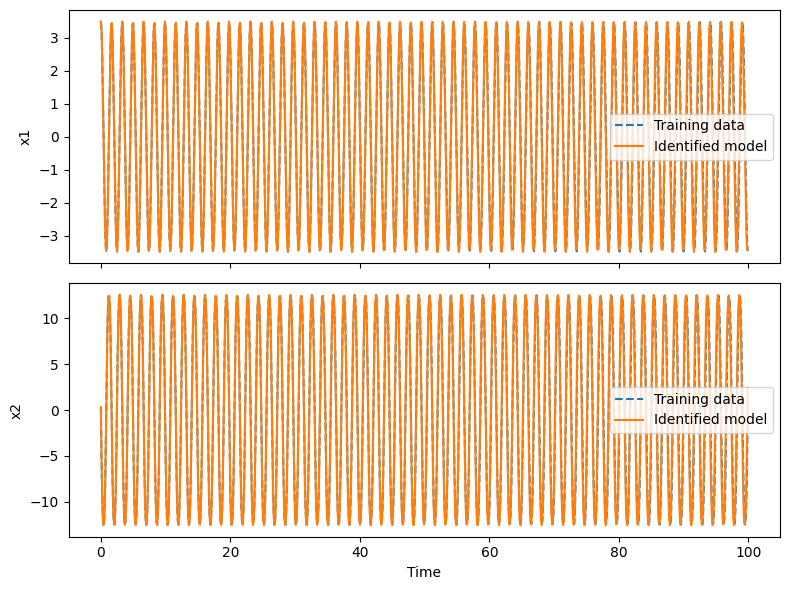

In [10]:
# Compare identified model simulation vs original training data
# Assumes model, x_train, data_T, data_dt are defined above
val_t_eval = np.arange(0, data_T, data_dt)

# Simulate identified model from the first training IC
sim_x = model.simulate(x_train[0], val_t_eval)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=x_train.shape[1], ncols=1, figsize=(8, 3 * x_train.shape[1]), sharex=True)
if x_train.shape[1] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(val_t_eval, x_train[:val_t_eval.shape[0], i], '--', label='Training data')
    ax.plot(val_t_eval, sim_x[:, i], label='Identified model')
    ax.set_ylabel(f'x{i+1}')
    ax.legend()

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()
